# 04 &mdash; Per-Model Visualizations

Notebook 03 delivered the statistical verdict: nine of ten models are
indistinguishable at $\alpha = 0.10$. This notebook turns that verdict
into pictures. Four figures, each answering a different question a
reader or reviewer will actually ask.

| Figure | Question it answers |
|---|---|
| `mae_convergence.png` | Did 60 origins settle the ranking, or would more origins change it? |
| `model_comparison_60.png` | How wide is each model's MAE distribution &mdash; do the means hide tail behavior? |
| `IBM_vs_RWD.png` | Does the foundation model lose on average *and* most of the time, or just occasionally? |
| `coffee_holdout_plot.png` | What do the actual forecast paths look like on a concrete test window? |

The first three run off the CSVs from notebook 01 and execute in
seconds. The fourth re-fits all ten models on the final holdout
window and takes several minutes; it sits in its own section at the
end so reviewers can skip it.

## 1. Setup

In [33]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from coffee_forecast.config import (
    COLOR_MAP,
    PLOT_ORDER,
    CSV_DIR,
    FIG_DIR,
    SCALES,
    CONTEXT_LEN,
    HORIZON,
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [34]:
summary = pd.read_csv(CSV_DIR / "summary_all_scales.csv")
step_errors = pd.read_csv(CSV_DIR / "step_errors_all_scales.csv")
print(f"summary_all_scales.csv      : {len(summary):>6} rows")
print(f"step_errors_all_scales.csv  : {len(step_errors):>6} rows")

summary_all_scales.csv      :   1010 rows
step_errors_all_scales.csv  :  63630 rows


## 2. MAE convergence across scales

Each model's mean MAE at scales 1, 10, 30, and 60. The question is
whether the ranking has *stabilized* by scale = 60 &mdash; if it hasn't,
the statistical tests in notebook 03 would be on shaky ground.

We show the x-axis equally spaced rather than linearly scaled, because
the four scales are geometric (1 → 10 → 30 → 60), not arithmetic.
Prophet's mean MAE swings wildly across scales and compresses the
other nine models into visual noise, so we use a broken y-axis to
keep both scales readable.

/var/folders/bb/jyf3hcfj6wn4256f5gz4c_7w0000gn/T/ipykernel_58868/145530567.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0, 1, 1])


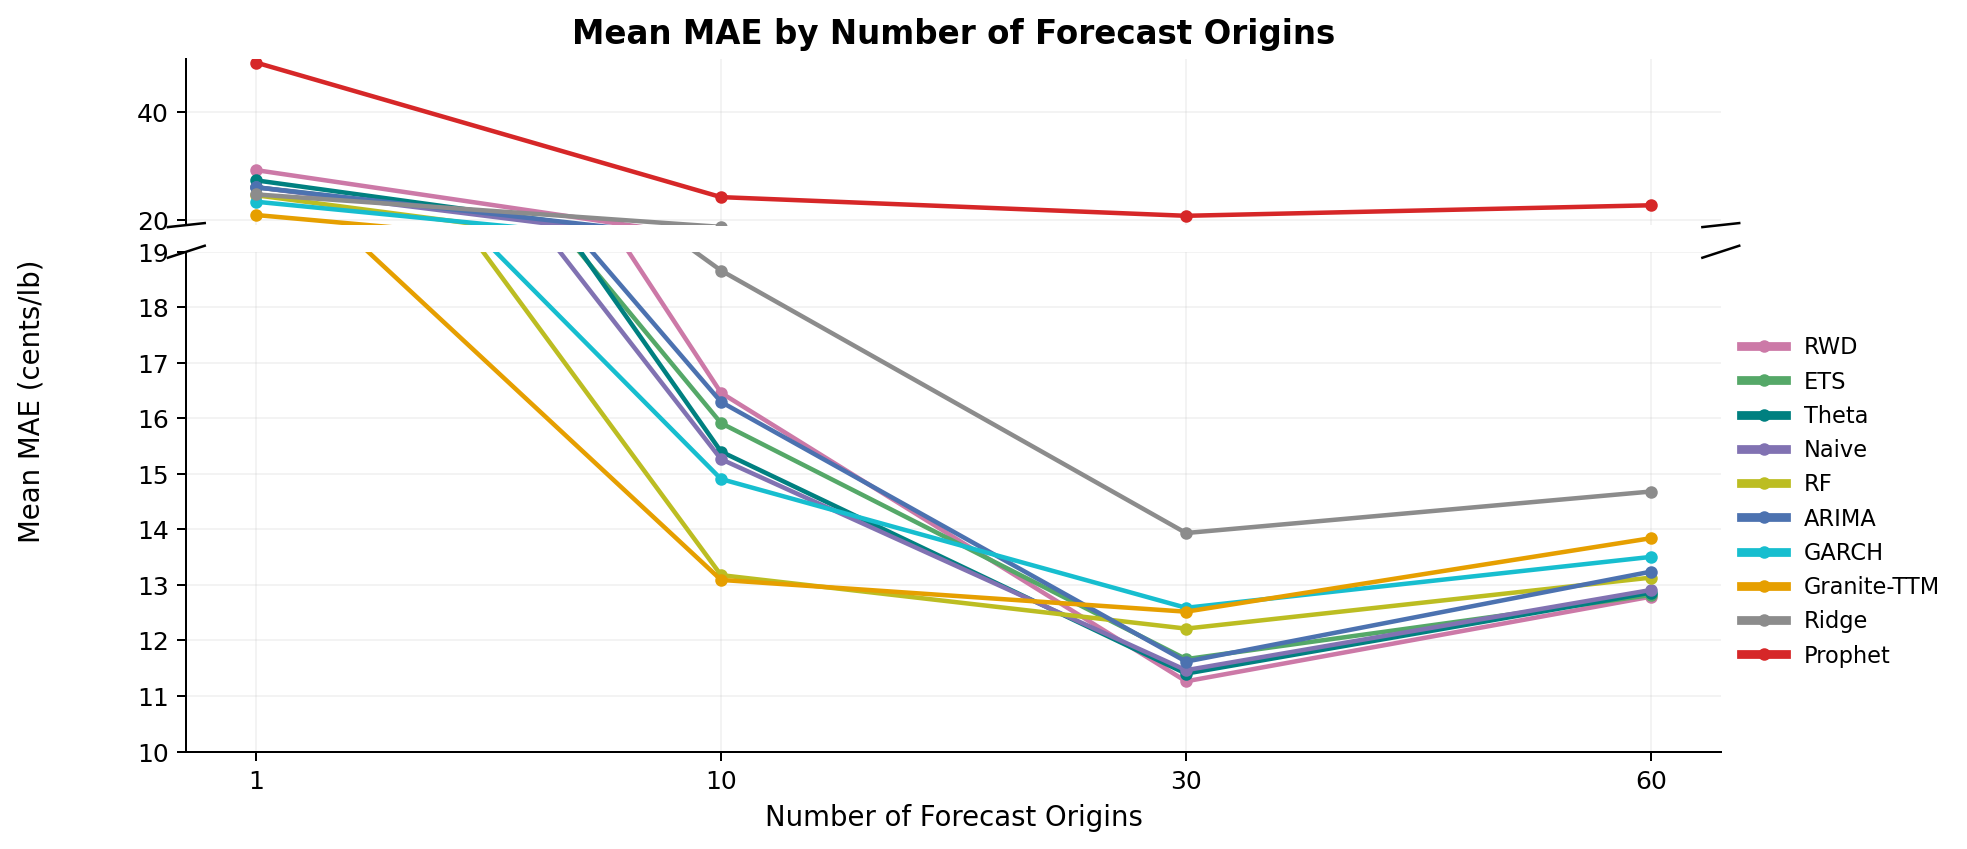

In [35]:
convergence = summary.groupby(["scale", "model"])["MAE"].mean().reset_index()
scale_positions = {s: i for i, s in enumerate(SCALES)}

fig = plt.figure(figsize=(11, 5), dpi=180)
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.08)
ax_top = fig.add_subplot(gs[0])  # Prophet's range
ax_bot = fig.add_subplot(gs[1])  # cluster of 9 other models

for name in PLOT_ORDER:
    data = convergence[convergence["model"] == name].sort_values("scale")
    x_pos = [scale_positions[s] for s in data["scale"]]
    style = dict(
        marker="o",
        color=COLOR_MAP.get(name, "#666666"),
        linewidth=1.8,
        markersize=4,
        label=name,
    )
    ax_top.plot(x_pos, data["MAE"], **style)
    ax_bot.plot(x_pos, data["MAE"], **style)

ax_top.set_ylim(19, 50)  # Prophet zone
ax_bot.set_ylim(10, 19)  # everyone-else zone

for ax in (ax_top, ax_bot):
    ax.set_xticks(range(len(SCALES)))
    ax.grid(True, alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)
ax_top.set_xticklabels([])
ax_bot.set_xticklabels(SCALES)

# Diagonal slash marks indicating broken axis
d = 0.012
k_top = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **k_top)
ax_top.plot((1 - d, 1 + d), (-d, +d), **k_top)
k_bot = dict(transform=ax_bot.transAxes, color="k", clip_on=False, linewidth=1)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **k_bot)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **k_bot)

fig.text(
    0.04, 0.5, "Mean MAE (cents/lb)", va="center", rotation="vertical", fontsize=11
)
ax_bot.set_xlabel("Number of Forecast Origins", fontsize=11)
ax_top.set_title(
    "Mean MAE by Number of Forecast Origins", fontsize=13, weight="semibold"
)

leg = ax_bot.legend(
    loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9
)
for line in leg.get_lines():
    line.set_linewidth(3.5)

fig.tight_layout(rect=[0.06, 0, 1, 1])
fig.savefig(FIG_DIR / "mae_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading this plot.** The lines of all non-Prophet models are nearly
flat from scale 30 to scale 60 &mdash; the ranking has stabilized. Prophet
is volatile across scales because it is sensitive to short context
windows and only partially stabilizes as more origins are added. Sixty
origins is sufficient to resolve the remaining ranking.

## 3. MAE distribution at 60 origins

The leaderboard in notebook 03 shows the *mean* MAE. That can hide
fat tails &mdash; a model that's average most of the time but occasionally
explodes will look worse than it deserves, and vice versa. Boxplots
show the full per-origin distribution: median, IQR, whiskers, and
individual origins that fell outside the whiskers.

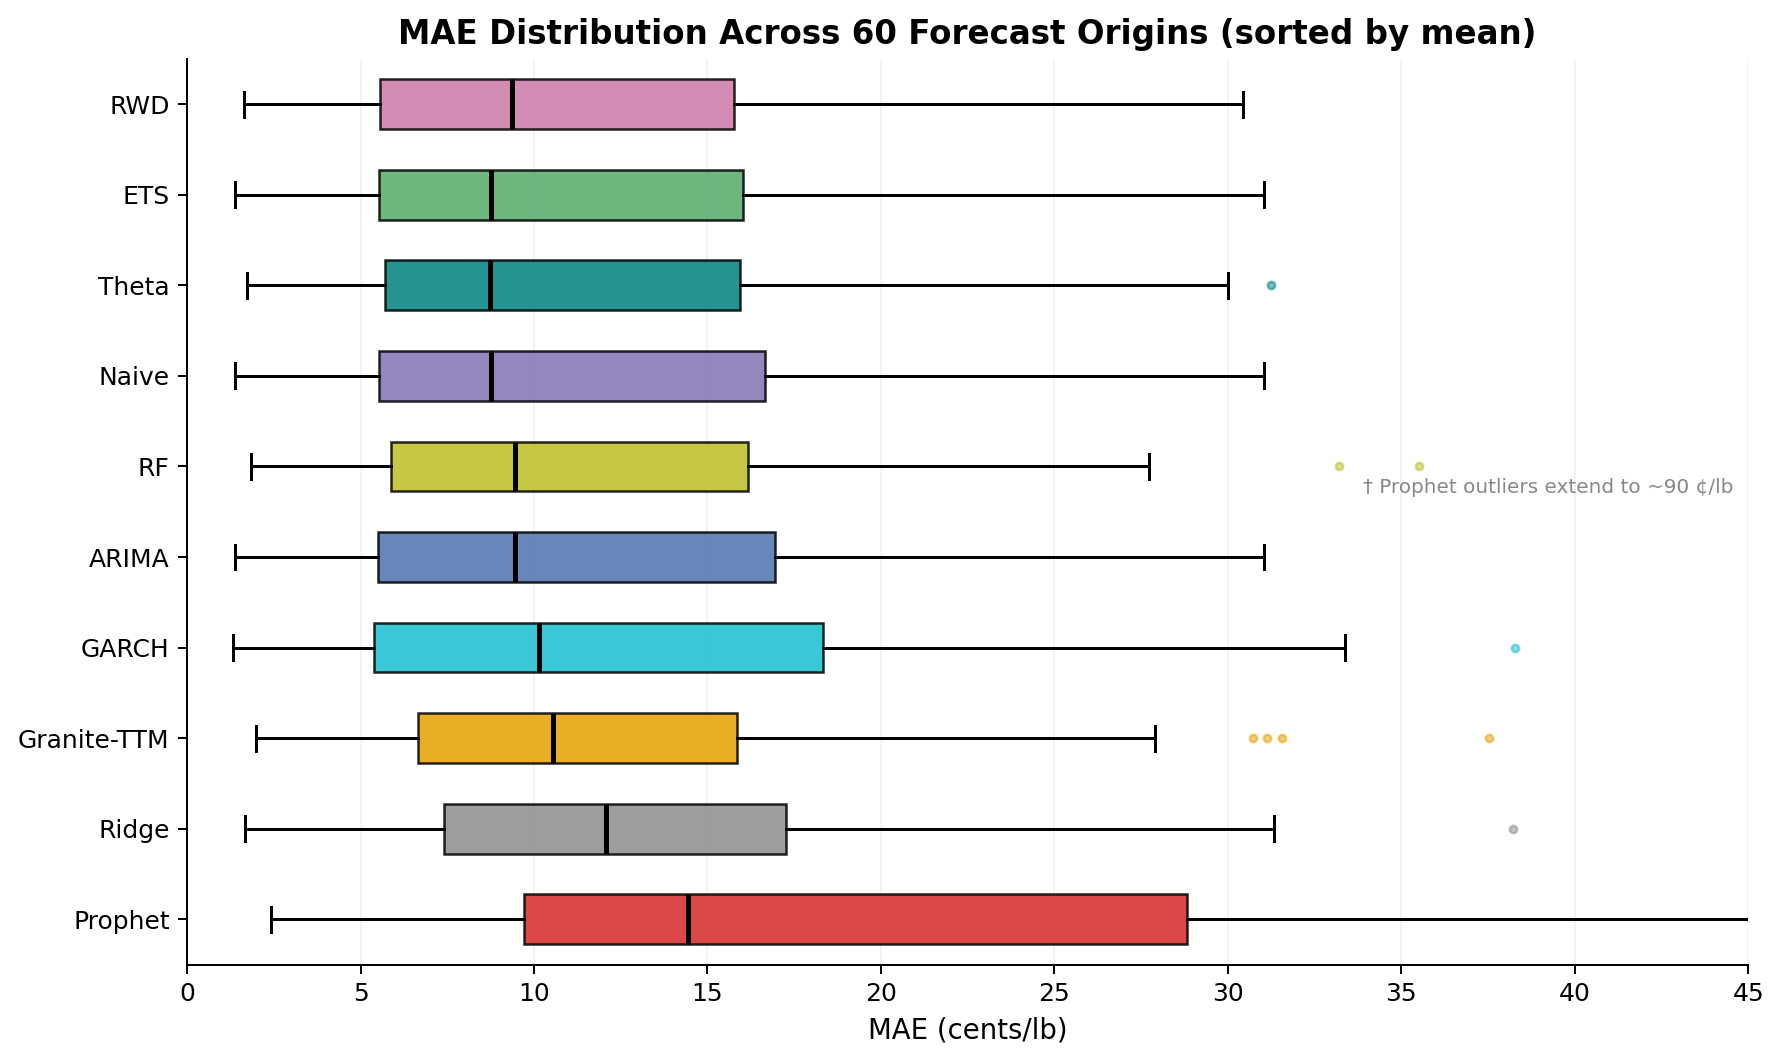

In [36]:
results_60 = summary[summary["scale"] == 60]
order = (
    results_60.groupby("model")["MAE"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
data = [results_60[results_60["model"] == m]["MAE"].values for m in order]

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
bp = ax.boxplot(
    data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    widths=0.55,
)
for patch, name in zip(bp["boxes"], order):
    patch.set_facecolor(COLOR_MAP.get(name, "#666666"))
    patch.set_alpha(0.85)
for flier, name in zip(bp["fliers"], order):
    flier.set_markerfacecolor(COLOR_MAP.get(name, "#666666"))
    flier.set_markeredgecolor(COLOR_MAP.get(name, "#666666"))

ax.set_xlim(0, 45)
ax.annotate(
    "† Prophet outliers extend to ~90 ¢/lb",
    xy=(45, 0.5),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="bottom",
    fontsize=8,
    color="#888",
    xytext=(-6, 6),
    textcoords="offset points",
)

ax.set_yticklabels(order, fontsize=10)
ax.set_title(
    "MAE Distribution Across 60 Forecast Origins (sorted by mean)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("MAE (cents/lb)", fontsize=11)
ax.grid(True, axis="x", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison_60.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading this plot.** The medians and IQRs of the top nine models
overlap heavily &mdash; the visual version of what MCS proved rigorously.
Prophet's box is shifted right *and* has a much longer right whisker:
it's worse on average *and* more unstable. That's why it's the one
model eliminated from the MCS.

## 4. Per-origin deep dive: IBM Granite TTM vs. RWD

When a foundation model loses to a random walk, the interesting
question is *how* it loses. Does it win often but occasionally
collapse? Or does it just underperform across the board? Plotting
per-origin MAE for both models tells that story directly.

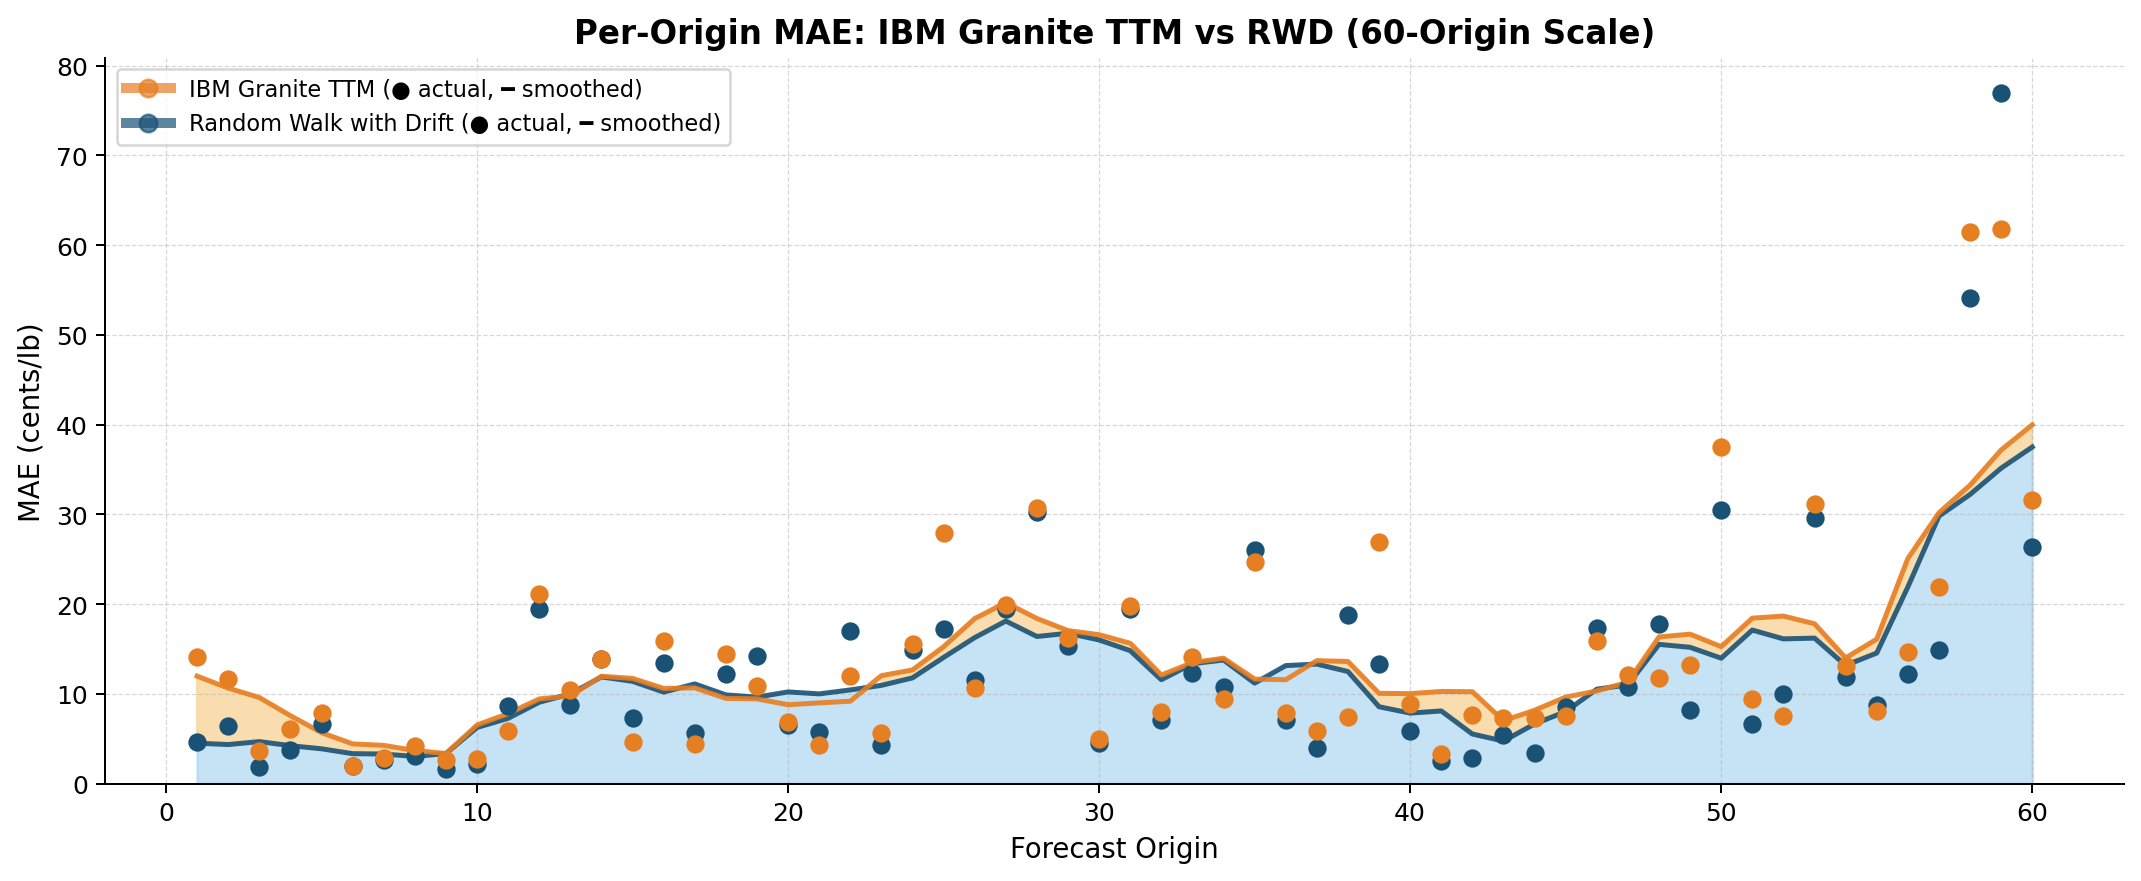


Granite beats RWD in 16 / 60 origins
Mean MAE: Granite = 13.842,  RWD = 12.789


In [37]:
from scipy.ndimage import uniform_filter1d

# Per-origin MAE = mean of per-step absolute errors over the 63-day horizon.
s60 = step_errors[step_errors["scale"] == 60]
rwd_mae = (
    s60[s60["model"] == "RWD"].groupby("origin_id")["error"].mean().sort_index().values
)
gra_mae = (
    s60[s60["model"] == "Granite-TTM"]
    .groupby("origin_id")["error"]
    .mean()
    .sort_index()
    .values
)
origin_ids = np.arange(1, len(rwd_mae) + 1)

# Smoothed trend to cut through origin-to-origin noise.
W = max(5, len(rwd_mae) // 10)
smooth_r = uniform_filter1d(rwd_mae.astype(float), size=W, mode="nearest")
smooth_g = uniform_filter1d(gra_mae.astype(float), size=W, mode="nearest")

fig, ax = plt.subplots(figsize=(12, 5), dpi=180)

# Blue base layer: 0 to RWD trend (shared forecast difficulty).
ax.fill_between(origin_ids, 0, smooth_r, color="#AED6F1", alpha=0.7)
# Orange layer: only where Granite exceeds RWD (the extra error).
ax.fill_between(
    origin_ids,
    smooth_r,
    smooth_g,
    where=(smooth_g >= smooth_r),
    color="#FAD7A0",
    alpha=0.85,
)

ax.plot(origin_ids, smooth_r, color="#1A5276", linewidth=2.0, alpha=0.9)
ax.plot(origin_ids, smooth_g, color="#E67E22", linewidth=2.0, alpha=0.9)
ax.scatter(origin_ids, rwd_mae, color="#1A5276", s=40, zorder=5)
ax.scatter(origin_ids, gra_mae, color="#E67E22", s=40, zorder=5)

ax.set_title(
    "Per-Origin MAE: IBM Granite TTM vs RWD (60-Origin Scale)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("Forecast Origin", fontsize=11)
ax.set_ylabel("MAE (cents/lb)", fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, ls="--", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="#E67E22",
        markerfacecolor="#E67E22",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="IBM Granite TTM (● actual, ━ smoothed)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="#1A5276",
        markerfacecolor="#1A5276",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="Random Walk with Drift (● actual, ━ smoothed)",
    ),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "IBM_vs_RWD.png", dpi=300, bbox_inches="tight")
plt.show()

granite_wins = int(np.sum(gra_mae < rwd_mae))
print(f"\nGranite beats RWD in {granite_wins} / {len(rwd_mae)} origins")
print(f"Mean MAE: Granite = {gra_mae.mean():.3f},  RWD = {rwd_mae.mean():.3f}")

**Reading this plot.** Granite has lower MAE than RWD at only 16 of
60 origins. The underperformance is not driven by a few outlier
windows; the orange-shaded area (Granite's excess error above RWD) is
nearly continuous, and the smoothed curves rarely cross. Neither the
32-year pretraining corpus nor the 1,536-day context window at each
origin translate into lower point-forecast error on this series.

---

## 5. Single holdout forecast: all 10 models on the final 63 trading days

*This section re-fits every model on the final context window. Expect
several minutes of runtime, dominated by Granite-TTM inference and
Prophet's Stan compilation.*

The earlier plots are aggregate views. This one is concrete: it shows
what each model's 63-day forecast **actually looks like** on a single
test window. Particularly useful for understanding *why* a model
performs the way it does &mdash; e.g., Prophet's mean-reverting curve vs.
Granite's flat extrapolation.

In [38]:
# --- Build the 10-model suite (same as notebook 01 / scripts/run_backtest.py) ---
import logging

for name in ("cmdstanpy", "prophet", "statsforecast"):
    logging.getLogger(name).setLevel(logging.ERROR)

import torch
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    Naive,
    RandomWalkWithDrift,
    Theta,
)
from tsfm_public.toolkit.get_model import get_model

from coffee_forecast import (
    load_coffee_data,
    calculate_metrics,
    StatsForecastWrapper,
    GARCHWrapper,
    ProphetWrapper,
    MLRecursiveWrapper,
    GraniteWrapper,
)
from coffee_forecast.config import SEED

device = "cuda" if torch.cuda.is_available() else "cpu"
ttm = (
    get_model(
        model_path="ibm-granite/granite-timeseries-ttm-r2",
        model_name="ttm",
        context_length=CONTEXT_LEN,
        prediction_length=96,
        prefer_longer_context=True,
        return_model_key=False,
    )
    .to(device)
    .eval()
)

models = {
    "Naive": StatsForecastWrapper(Naive(alias="Naive")),
    "RWD": StatsForecastWrapper(RandomWalkWithDrift(alias="RWD")),
    "Theta": StatsForecastWrapper(Theta(season_length=252, alias="Theta")),
    "ETS": StatsForecastWrapper(AutoETS(alias="ETS")),
    "ARIMA": StatsForecastWrapper(AutoARIMA(seasonal=False, alias="ARIMA")),
    "GARCH": GARCHWrapper(),
    "Prophet": ProphetWrapper(),
    "Ridge": MLRecursiveWrapper(make_pipeline(StandardScaler(), Ridge())),
    "RF": MLRecursiveWrapper(
        RandomForestRegressor(n_estimators=100, random_state=SEED)
    ),
    "Granite-TTM": GraniteWrapper(ttm, device, context_len=CONTEXT_LEN),
}
print(f"{len(models)} models ready.")

INFO:p-58868:t-8514574528:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-58868:t-8514574528:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-58868:t-8514574528:get_model.py:get_model:[TTM] context_length = 1536, prediction_length = 96


10 models ready.


In [39]:
df = load_coffee_data()
a = len(df) - HORIZON  # final holdout origin
context_df = df.iloc[a - CONTEXT_LEN : a].copy()
test_df = df.iloc[a : a + HORIZON].copy()
y_true = test_df["y"].to_numpy(dtype=float)
train_y = context_df["y"].to_numpy(dtype=float)
test_start = test_df["ds"].iloc[0]

# Generate forecasts.
plot_df = pd.DataFrame({"ds": test_df["ds"].to_numpy(), "Actual": y_true})
for name, wrapper in models.items():
    try:
        plot_df[name] = wrapper.predict(context_df, HORIZON)
        print(f"  ✓ {name}")
    except Exception as e:
        print(f"  ✗ {name}: {e}")

# Single-origin metrics, sorted by MAE.
rows = []
for name in PLOT_ORDER:
    if name not in plot_df.columns:
        continue
    y_hat = plot_df[name].to_numpy(dtype=float)
    if np.any(~np.isfinite(y_hat)):
        continue
    metrics = calculate_metrics(y_true, y_hat, train_y)
    metrics["Model"] = name
    rows.append(metrics)

holdout_metrics = (
    pd.DataFrame(rows)
    .sort_values("MAE")
    .reset_index(drop=True)[["Model", "MAE", "RMSE", "sMAPE", "MASE"]]
)
holdout_metrics.to_csv(CSV_DIR / "single_origin_metrics.csv", index=False)
print("\nSaved: results/csv/single_origin_metrics.csv")
holdout_metrics.round(3)

  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Saved: results/csv/single_origin_metrics.csv


,Model,MAE,RMSE,sMAPE,MASE
0,Granite-TTM,20.875,22.601,0.055,5.781
1,GARCH,23.348,25.852,0.062,6.466
2,RF,24.552,26.087,0.065,6.800
3,Ridge,24.709,29.209,0.065,6.843
4,ETS,26.039,29.876,0.069,7.212
5,Naive,26.039,29.876,0.069,7.212
6,ARIMA,26.044,29.927,0.069,7.213
7,Theta,27.325,31.971,0.072,7.568
8,RWD,29.231,35.043,0.077,8.096
9,Prophet,49.243,60.306,0.124,13.638


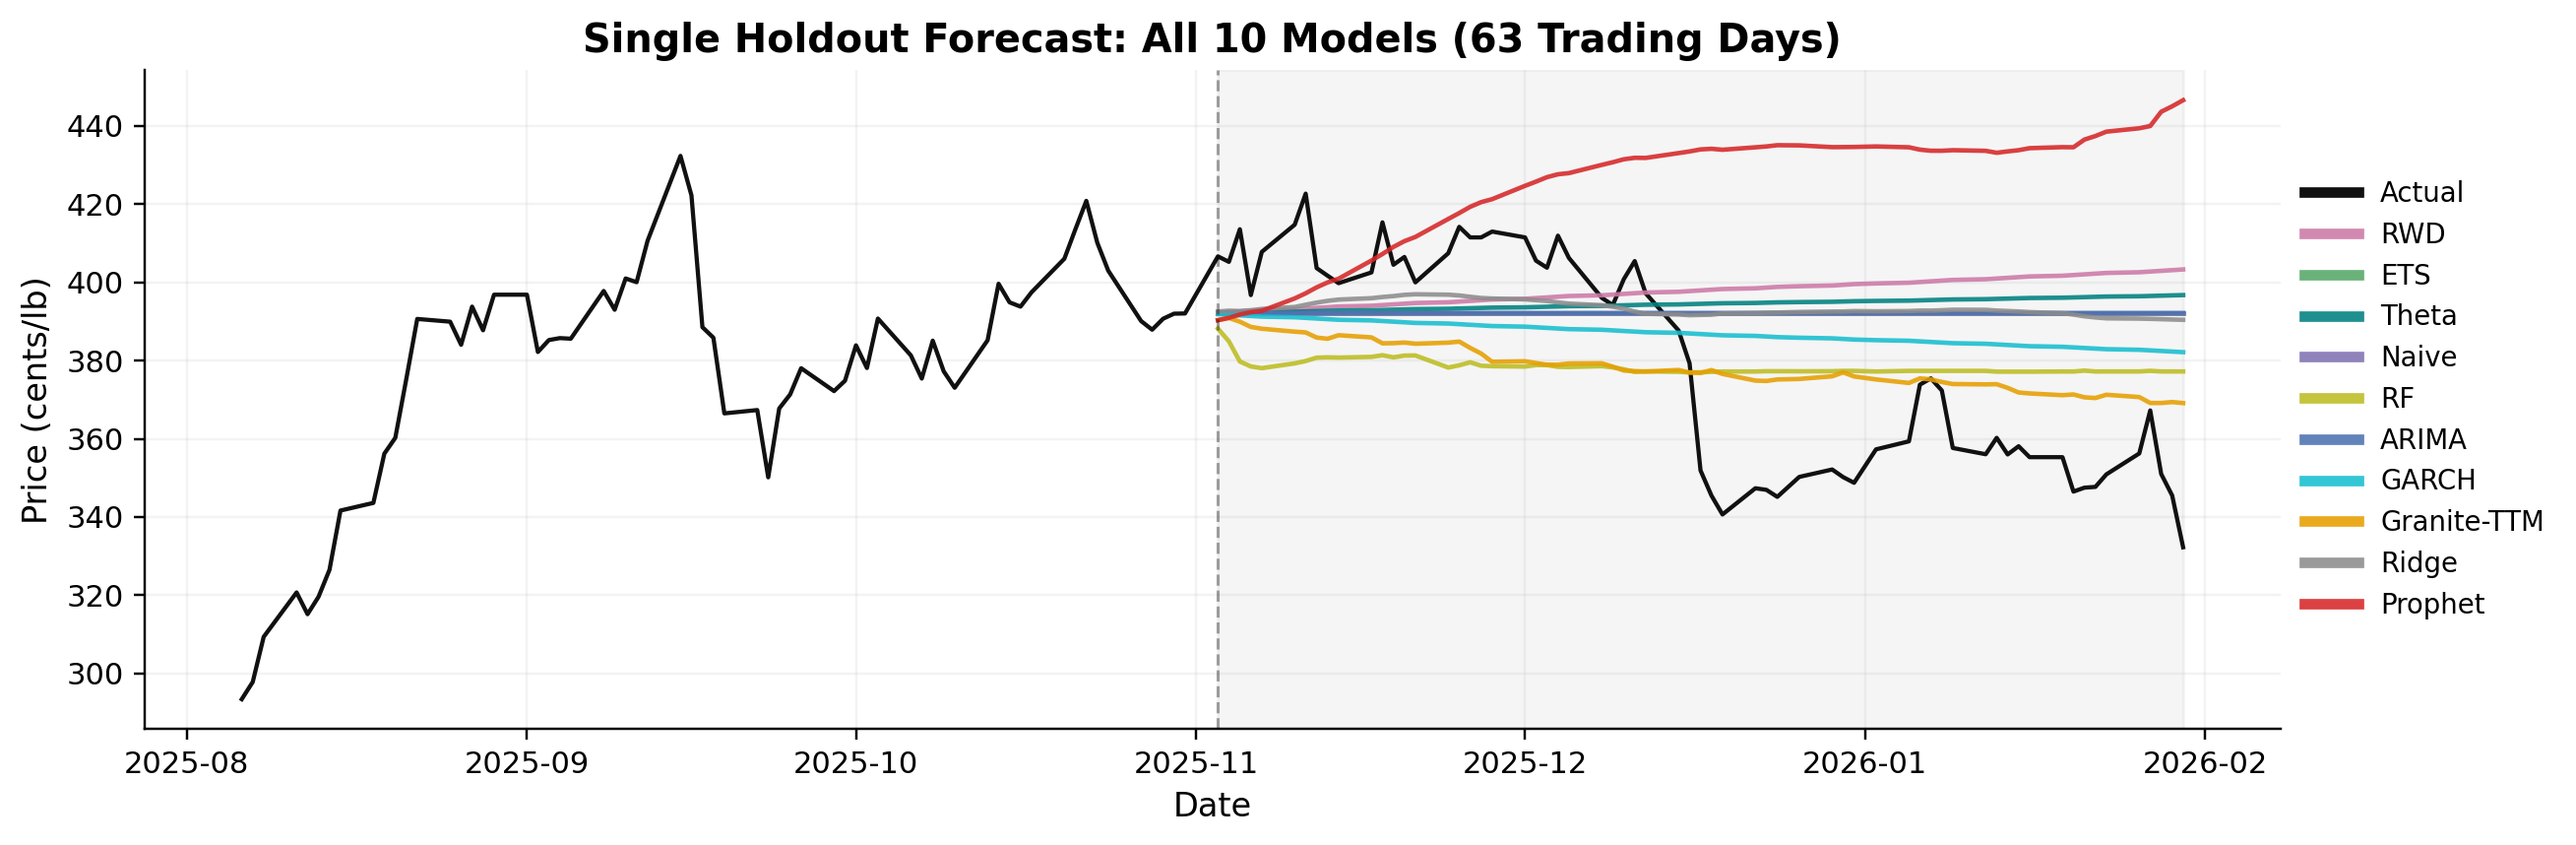

In [40]:
# Show the last 63 trading days *before* the holdout too so the forecast
# isn't floating in space.
vis_start = max(0, a - HORIZON)
vis_df = df.iloc[vis_start : a + HORIZON][["ds", "y"]]

fig, ax = plt.subplots(figsize=(12, 4), dpi=220)
ax.axvspan(test_start, vis_df["ds"].max(), color="gray", alpha=0.08)
ax.plot(
    vis_df["ds"], vis_df["y"], color=COLOR_MAP["Actual"], linewidth=1.4, label="Actual"
)

for name in PLOT_ORDER:
    if name not in plot_df.columns:
        continue
    y_hat = plot_df[name].to_numpy(dtype=float)
    if np.any(~np.isfinite(y_hat)):
        continue
    ax.plot(
        plot_df["ds"],
        y_hat,
        color=COLOR_MAP.get(name, "#666"),
        linewidth=1.5,
        alpha=0.88,
        label=name,
    )

ax.axvline(test_start, ls="--", linewidth=1, color="black", alpha=0.35)
ax.set_title(
    "Single Holdout Forecast: All 10 Models (63 Trading Days)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (cents/lb)", fontsize=11)
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
for line in leg.get_lines():
    line.set_linewidth(3.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "coffee_holdout_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading this plot.** Each model's 63-day forecast, overlaid with
the realized path:

- **Naive, ETS, ARIMA** forecast a nearly flat line at the last
  observed price &mdash; the behavior expected under the near-random-walk
  prior. RWD adds a small drift term, which on this particular window
  tracks the early part of the realized path.
- **Granite-TTM** produces a smoothly curving forecast with gentle
  mean reversion, a pattern shaped by its pretraining distribution.
- **Prophet** extrapolates the recent upward trend aggressively,
  projecting the price well above the realized path.
- **GARCH** produces a conservative mean forecast with small
  variation, consistent with its low point-forecast MAE on this
  window.

The visual matches the near-random-walk prior from notebook 02:
models that assume exploitable structure (Prophet, Granite-TTM)
produce more confident paths that can miss substantially, while
models that forecast flat from the last observation stay close to the realized
trajectory.

---

**Next notebook:** `05_deployment_garch.ipynb` &mdash; extends GARCH's
point-forecast performance with the GJR asymmetric volatility term
and Student-t errors to produce calibrated prediction intervals for
the live forecast.